In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [33]:
df = pd.read_csv("Public_Bus_Operations_Multi_Target.csv")

In [34]:
df.head()

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


In [35]:
df.shape

(10000, 11)

Number of Rows: 10000. <br>
Number of Columns: 11. <br>
each row represents one historical bus trip.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  10000 non-null  object 
 1   weather_condition        9742 non-null   object 
 2   bus_type                 9798 non-null   object 
 3   traffic_level            10000 non-null  object 
 4   route_distance_km        9849 non-null   float64
 5   stops_count              10000 non-null  int64  
 6   passenger_count          9818 non-null   float64
 7   driver_experience_years  9777 non-null   float64
 8   scheduled_start_hour     10000 non-null  int64  
 9   delay_level              10000 non-null  object 
 10  trip_duration_minutes    10000 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 859.5+ KB


In [37]:
df.describe()

,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,trip_duration_minutes
count,9849.000000,10000.000000,9818.000000,9777.000000,10000.000000,10000.000000
mean,10.622125,11.227500,30.434101,6.151693,13.957900,60.837522
std,5.489059,6.064505,12.695660,3.999918,5.501323,33.956659
min,2.000000,3.000000,3.000000,0.200000,5.000000,12.000000
25%,6.530000,7.000000,21.000000,3.140000,9.000000,36.660000
50%,9.600000,10.000000,31.000000,5.280000,14.000000,52.335000
75%,13.660000,15.000000,39.000000,8.270000,19.000000,76.490000
max,32.000000,37.000000,65.000000,18.000000,23.000000,180.000000


In [38]:
df.describe(include="O")

,trip_id,weather_condition,bus_type,traffic_level,delay_level
count,10000,9742,9798,10000,10000
unique,9850,4,3,4,3
top,TRIP204870,Clear,Standard,Moderate,On Time
freq,2,5305,5594,3785,3334


In [39]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                         Missing Count  Missing %
weather_condition                  258       2.58
bus_type                           202       2.02
route_distance_km                  151       1.51
passenger_count                    182       1.82
driver_experience_years            223       2.23


In [40]:
df.duplicated().sum()

np.int64(150)

quality problems: <br>
150 duplicated rows. <br>
missing values in 5 columns.

In [41]:
classification_target_counts = df['delay_level'].value_counts()
target_pct = df['delay_level'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Count': classification_target_counts, 'Percentage': target_pct.round(1)}))

                Count  Percentage
delay_level                      
On Time          3334        33.3
Moderate Delay   3333        33.3
Severe Delay     3333        33.3


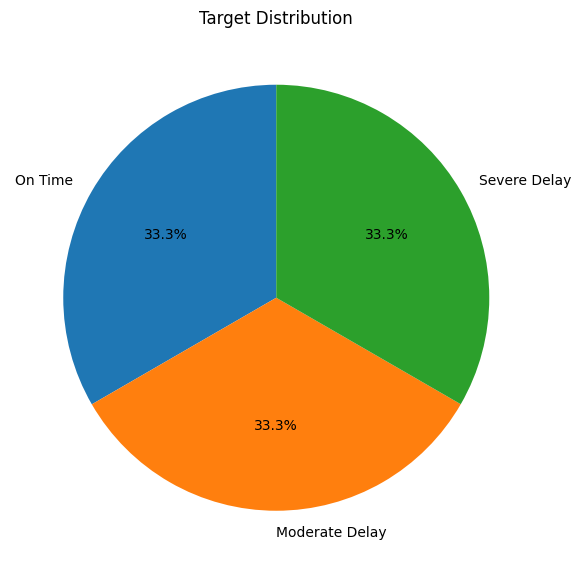

In [42]:
plt.figure(figsize=(6, 6))
plt.pie(classification_target_counts, labels=classification_target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

All the classes are balanced.

In [43]:
df["trip_duration_minutes"].describe()

count    10000.000000
mean        60.837522
std         33.956659
min         12.000000
25%         36.660000
50%         52.335000
75%         76.490000
max        180.000000
Name: trip_duration_minutes, dtype: float64

<Axes: xlabel='trip_duration_minutes', ylabel='Count'>

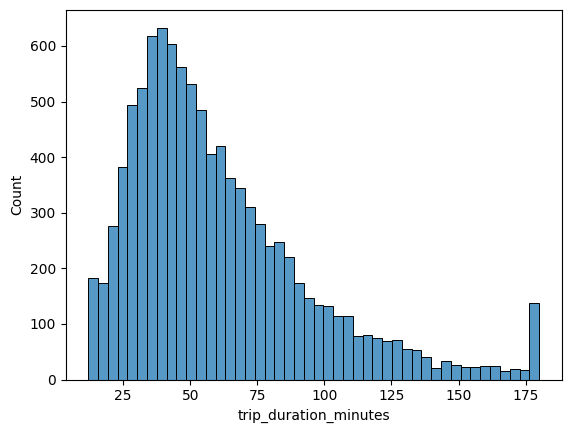

In [44]:
sns.histplot(data=df, x="trip_duration_minutes")

<Axes: xlabel='trip_duration_minutes'>

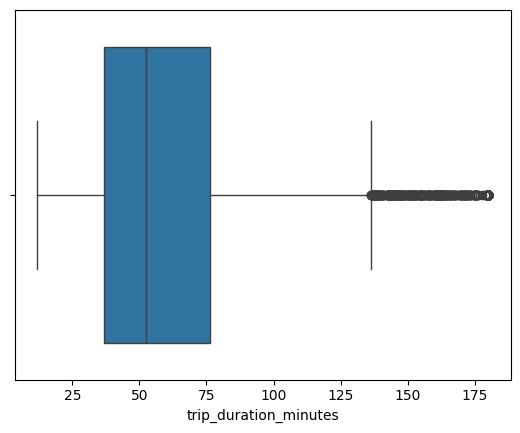

In [45]:
sns.boxplot(data=df, x="trip_duration_minutes")

medical trip is about 52 minutes. <br>
range: 12-180 minutes. <br>
trip_duration_minutes is right (positive) skewed. <br>
there are some extreme values from 135m-180m, especially at 180m, and this can cause prediction errors.

### Numerical Features vs the Classification Target

Which numerical features affect the classification target ?

In [46]:
df['delay_level_flag'] = df['delay_level'].map({
    'On Time': 0,
    'Moderate Delay': 1,
    "Severe Delay": 2
})

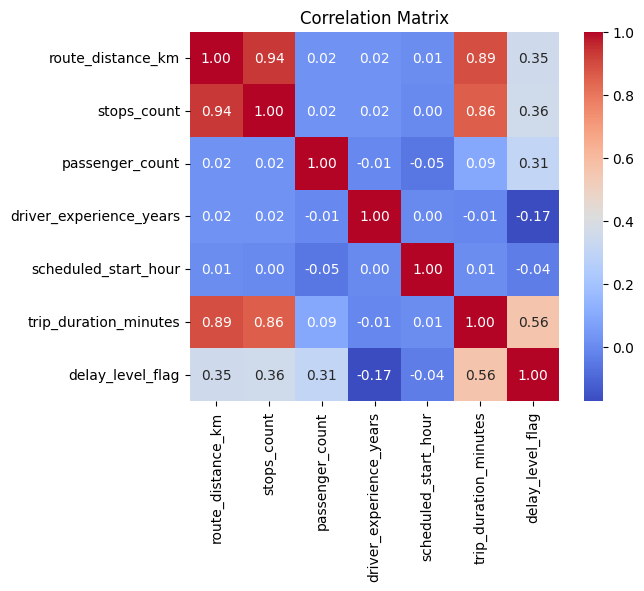

In [47]:
numeric_for_correlation = df.select_dtypes(include=['number']).corr()
sns.heatmap(numeric_for_correlation, annot=True, fmt='.2f', square=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

trip duration minutes do affect delay level. <br>
and this is usual. <br>
Also route distance, stops count and passenger count affect it to an extent.

In [48]:
df.head()

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes,delay_level_flag
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84,1
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26,1
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64,0
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70,2
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37,0


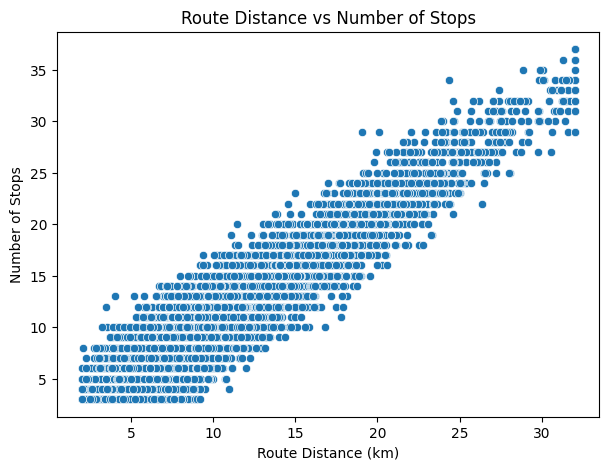

In [49]:
#Is route distance related to stops count ?

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="route_distance_km", y="stops_count")

plt.xlabel("Route Distance (km)")
plt.ylabel("Number of Stops")
plt.title("Route Distance vs Number of Stops")
plt.show()

As the route distance increases the number of stops increases. <br>
this means number of people get on and get down increases by increasing distance.

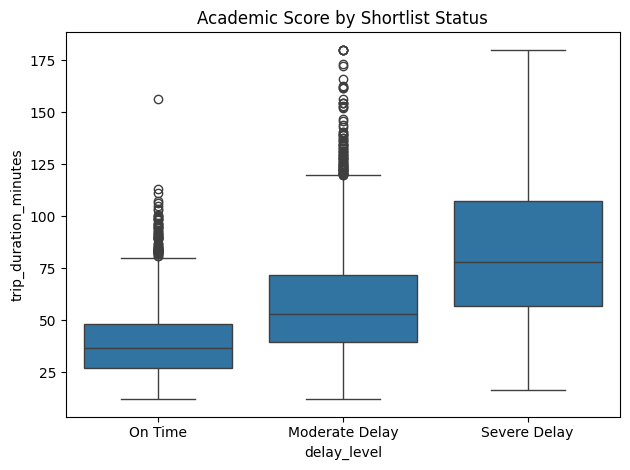

In [50]:
sns.boxplot(data=df, x='delay_level', y='trip_duration_minutes', order=['On Time', 'Moderate Delay', "Severe Delay"])
plt.title('Academic Score by Shortlist Status')
plt.tight_layout()
plt.show()

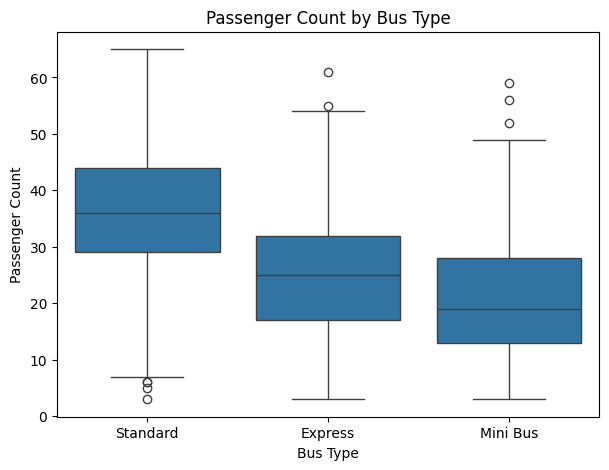

In [51]:
#Does passenger count vary across bus types?


plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="bus_type", y="passenger_count", order=["Standard", "Express", "Mini Bus"])
plt.xlabel("Bus Type")
plt.ylabel("Passenger Count")
plt.title("Passenger Count by Bus Type")
plt.show()

More pepople prefer Standard busses then express ones then mini busses

In [52]:
#dropping duplicates causing wrong predictions

clean_df = (df.drop_duplicates().drop(columns=['trip_id', 'delay_level_flag']).reset_index(drop=True))

In [53]:
clean_df.shape

(9850, 10)

In [54]:
feature_columns = [
    'weather_condition',
    'bus_type',
    'traffic_level',
    'route_distance_km',
    'stops_count',
    'passenger_count',
    'driver_experience_years',
    'scheduled_start_hour'
]

X = clean_df[feature_columns]
y_delay = clean_df['delay_level']
y_duration = clean_df['trip_duration_minutes']

print(X.shape)
print(y_delay.shape)
print(y_duration.shape)

(9850, 8)
(9850,)
(9850,)


In [55]:
X_train, X_test, y_delay_train, y_delay_test, y_duration_train, y_duration_test = train_test_split(
    X,
    y_delay,
    y_duration,
    test_size=0.20,
    random_state=42,
    stratify=y_delay
)

print(X_train.shape, X_test.shape)
print(y_delay_train.shape, y_delay_test.shape)
print(y_duration_train.shape, y_duration_test.shape)

(7880, 8) (1970, 8)
(7880,) (1970,)
(7880,) (1970,)


In [56]:
clean_df.head()

,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


80/20 random train test split was used

In [57]:
nominal_features = ['weather_condition', 'bus_type']
ordinal_features = ['traffic_level']
numerical_features = ['route_distance_km', 'stops_count', 'passenger_count',
                    'driver_experience_years', 'scheduled_start_hour']

In [58]:
classification_target_counts = df['traffic_level'].value_counts()
target_pct = df['traffic_level'].value_counts(normalize=True).round(4) * 100
display(pd.DataFrame({'Count': classification_target_counts, 'Percentage': target_pct.round(1)}))

,Count,Percentage
traffic_level,,
Moderate,3785,37.8
High,3051,30.5
Low,1836,18.4
Severe,1328,13.3


In [59]:
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[
        ['Low', 'Moderate', 'High', 'Severe']
    ]))
])
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

In [60]:
preprocessor_full = ColumnTransformer(
    transformers=[
        ('nominal', nominal_pipeline, nominal_features),
        ('ordinal', ordinal_pipeline, ordinal_features),
        ('numerical', numerical_pipeline, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

In [61]:
preprocessor_selected = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_pipeline, ordinal_features),
        ('numerical', numerical_pipeline, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

In [69]:
model_search_space = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'parameters': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'SVC': {
        'model': SVC(random_state=42),
        'parameters': {
            'model__kernel': ['linear', 'rbf'],
            'model__C': [0.1, 1, 10],
            'model__gamma': ['scale', 0.1],
            'model__class_weight': [None, 'balanced'],
        },
    }
}

In [70]:
def run_gridsearch(X_train, y_train, preprocessor, model_search_space, random_state=42):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    search_results = {}
    rows = []
    for model_name, specification in model_search_space.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', specification['model']),
        ])
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification['parameters'],
            scoring='f1', cv=cv, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        search_results[model_name] = search
        rows.append({'Model': model_name, 'Best Mean CV F1': search.best_score_})
    comparison_df = (pd.DataFrame(rows)
                    .sort_values('Best Mean CV F1', ascending=False)
                    .reset_index(drop=True))
    return comparison_df, search_results